# Drogued Drifter in an Idealized Sheared Flow with Parcels

A drogued drifter is a surface buoy connected by a rigid pole to a subsurface drogue. The drogue anchors the drifter to a target depth so that the buoy tracks currents at that depth rather than being blown by wind and surface waves. But the buoy still feels surface drag, so the actual drift velocity is a compromise between the surface current (acting on the buoy) and the deeper current (acting on the drogue). Under sufficient shear, the pole can tilt, and the drogue can drift at depths shallower than its equilibrium depth. The `DroguedDrifter` model computes this compromise from the full equations of motion.

This notebook demonstrates the drogued drifter model coupled to [Parcels v4](https://github.com/OceanParcels/parcels) in a synthetic 3D velocity field. We compare three types of Lagrangian particles:

1. **Drogued drifters**: advected at the steady-state drift velocity of the buoy+drogue system.
2. **Surface point particles**: advected at z = 0 (the fastest current).
3. **Drogue-depth point particles**: advected at the equilibrium drogue depth.

The drogued drifter should travel at an intermediate speed, between the surface and drogue-depth point particles.

## Imports

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable
from parcels._core.statuscodes import FieldOutOfBoundError
from parcels.kernels import AdvectionEE, AdvectionRK4
from scipy.special import erf

from drogued_drifters.drifter import DroguedDrifter, make_dd_velocity_interpolator

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_82124/730951821.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable


## Physical parameters

The velocity field consists of two opposing meandering jets on a flat Cartesian grid. The current decays exponentially with depth and rotates clockwise (Ekman-like), creating vertical shear that the drogued drifter model must resolve.

**Flow parameters:**
- `U_0`: peak surface current speed.
- `H`: e-folding depth for vertical decay. At depth `H`, the current is reduced to ~37% of its surface value.
- `L_Y`: meridional Gaussian half-width of each jet.
- `JET_SEP`: meridional distance between jet centres.
- `A_MEANDER`, `MEANDER_WAVELENGTH`: amplitude and wavelength of the sinusoidal jet meander.
- `MEANDER_PHASE_DEG`: phase offset between the two jets (in degrees).

**Drifter parameter:**
- `DROGUE_DEPTH`: depth of the drogue below the surface (3 m for the [Callies et al. (2017)](https://doi.org/10.5194/os-13-799-2017) drifter design).

In [2]:
U_0 = 2.0              # peak surface current [m/s]
H = 3.0                # e-folding depth [m]
L_Y = 5_000.0          # jet half-width [m]
JET_SEP = 12_000.0     # separation between jet centres [m]
A_MEANDER = 3_000.0    # meander amplitude [m]
MEANDER_WAVELENGTH = 30_000.0  # meander wavelength [m]
MEANDER_PHASE_DEG = 60.0       # phase offset between jets [deg]

ROTATION_DEG_0 = 20.0     # rotation at surface [deg/e-fold]
ROTATION_DEG_DEEP = 90.0  # rotation at depth [deg/e-fold]
Z_ROT = 5.0               # depth scale for rotation increase [m]

DROGUE_DEPTH = 3.0  # drogue depth [m]

NX = 300              # grid x-dimension
NY = 150              # grid y-dimension
NZ = 20               # grid z-dimension
DT = 300.0            # timestep: 5 min [s]
RUNTIME = 86400.0     # total: 24 hours [s]
OUTPUTDT = 300.0      # output every 5 min
OUTPUT_DIR = "output"

## Build the velocity field

We use a **streamfunction** to prescribe the surface flow — not because non-divergence is important here, but because it is a convenient way to define a smooth, interesting flow pattern with meandering jets.

Each jet has a Gaussian cross-section with sinusoidal meanders. The streamfunction is

$$\psi_i(x, y) = -U_i \, L_Y \, \frac{\sqrt{\pi}}{2} \, \operatorname{erf}\!\left(\frac{y - y_{c,i}(x)}{L_Y}\right)$$

where $y_{c,i}(x)$ is the meandering centreline and $\operatorname{erf}$ is the error function (the antiderivative of the Gaussian $e^{-t^2}$, up to normalization). The velocity components follow from $U_s = -\partial\psi/\partial y$ and $V_s = \partial\psi/\partial x$.

The two jets flow in opposite directions (jet 1 eastward, jet 2 westward) and have different meander phases. The surface velocity decays exponentially with depth and rotates clockwise, mimicking Ekman dynamics:

$$\begin{pmatrix} U \\ V \end{pmatrix} = e^{-z/H} \begin{pmatrix} \cos\alpha(z) & -\sin\alpha(z) \\ \sin\alpha(z) & \cos\alpha(z) \end{pmatrix} \begin{pmatrix} U_s \\ V_s \end{pmatrix}$$

where the rotation rate increases with depth:

$$\alpha(z) = -\frac{z}{H}\left[\alpha_0 + (\alpha_\infty - \alpha_0)\left(1 - e^{-z/z_r}\right)\right]$$

with $\alpha_0 = 20°$/e-fold at the surface increasing to $\alpha_\infty = 90°$/e-fold at depth, over a scale $z_r = 5$ m.

In [3]:
K_MEANDER = 2 * np.pi / MEANDER_WAVELENGTH
MEANDER_PHASE = np.deg2rad(MEANDER_PHASE_DEG)

x = np.linspace(-200_000, 200_000, NX)
y = np.linspace(-50_000, 50_000, NY)
depth = np.linspace(0, 100, NZ)
time = np.array([0.0])

Z, Y, X = np.meshgrid(depth, y, x, indexing="ij")

# Meandering jet centrelines
y_c1 = JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X)
y_c2 = -JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X + MEANDER_PHASE)
dy_c1_dx = A_MEANDER * K_MEANDER * np.cos(K_MEANDER * X)
dy_c2_dx = A_MEANDER * K_MEANDER * np.cos(K_MEANDER * X + MEANDER_PHASE)

eta1 = (Y - y_c1) / L_Y
eta2 = (Y - y_c2) / L_Y

# Surface velocity from streamfunction derivatives
U_surface = U_0 * np.exp(-eta1**2) - U_0 * np.exp(-eta2**2)
V_surface = U_0 * np.exp(-eta1**2) * dy_c1_dx - U_0 * np.exp(-eta2**2) * dy_c2_dx

# Depth decay with Ekman-like rotation
rot_deg_z = ROTATION_DEG_0 + (ROTATION_DEG_DEEP - ROTATION_DEG_0) * (1 - np.exp(-Z / Z_ROT))
angle = -np.radians(rot_deg_z) * Z / H
decay = np.exp(-Z / H)

U_data = (U_surface * decay * np.cos(angle) - V_surface * decay * np.sin(angle))[np.newaxis, ...]
V_data = (U_surface * decay * np.sin(angle) + V_surface * decay * np.cos(angle))[np.newaxis, ...]

# Build xarray Dataset with SGRID metadata
ds = xr.Dataset(
    {
        "U": (["time", "depth", "y", "x"], U_data),
        "V": (["time", "depth", "y", "x"], V_data),
        "grid": xr.DataArray(
            data=0,
            attrs={
                "cf_role": "grid_topology",
                "topology_dimension": 2,
                "node_dimensions": "x y",
                "face_dimensions": "x:x (padding: none) y:y (padding: none)",
                "vertical_dimensions": "depth:depth (padding: none)",
                "node_coordinates": "x y",
            },
        ),
    },
    coords={
        "x": ("x", x, {"axis": "X"}),
        "y": ("y", y, {"axis": "Y"}),
        "depth": ("depth", depth, {"axis": "Z"}),
        "time": ("time", time, {"axis": "T"}),
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds, mesh="flat")

## Define the drogued drifter interpolator

We replace the default velocity interpolator on `fieldset.UV` with a custom one that runs the full drogued drifter model. At each Parcels timestep, the interpolator:

1. Extracts the velocity profile at all depth levels for each particle (bilinear interpolation in t, y, x — reusing the grid search).
2. Builds a fast depth interpolator from the cached profiles.
3. Runs `DroguedDrifter.get_final_drift_batch` with the profile sampler.
4. Returns the steady-state drift velocity as (u, v).

From Parcels' perspective, the drifter model is just a custom velocity interpolator. `AdvectionEE` applies the returned drift velocity directly.

In [4]:
dd = DroguedDrifter()
dd_warm_state = {}

# Replace the default velocity interpolator with the drogued drifter model
fieldset.UV.vector_interp_method = make_dd_velocity_interpolator(
    dd, warm_state=dd_warm_state,
)

# For the point particle runs, we need a separate FieldSet with the
# default interpolator. Copy the dataset and rebuild.
fieldset_pp = FieldSet.from_sgrid_conventions(ds, mesh="flat")


def DeleteOOB(particles, fieldset):
    """Convert out-of-bounds errors to Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

## Run simulations

We release particles in a grid spanning both jets at several x-positions. Three simulations:

1. **Drogued drifter**: `AdvectionEE` on the DD-interpolated FieldSet (the custom interpolator returns the steady-state drift velocity).
2. **Surface point particle**: `AdvectionRK4` at z=0 on a standard FieldSet.
3. **Drogue-depth point particle**: `AdvectionRK4` at z=3m on a standard FieldSet.

In [5]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

# Release grid: 5 x-positions, 10 y-positions spanning both jets
_lats = np.linspace(-JET_SEP / 2 - 2 * L_Y, JET_SEP / 2 + 2 * L_Y, 10)
_x_positions = np.linspace(5_000, 25_000, 5)
_lon_grid, _lat_grid = np.meshgrid(_x_positions, _lats)
release_lons = _lon_grid.ravel().tolist()
release_lats = _lat_grid.ravel().tolist()
n_particles = len(release_lats)

In [6]:
# Drogued drifter run — AdvectionEE with custom DD velocity interpolator
dd_store = str(output_dir / "01_drogued_drifter.zarr")
shutil.rmtree(dd_store, ignore_errors=True)

pset_drifter = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons,
    lat=release_lats,
    z=[0] * n_particles,
)
pset_drifter.execute(
    kernels=[AdvectionEE, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=dd_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/examples/idealized_flow/output/01_drogued_drifter.zarr


/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:281: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(
/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:286: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(
/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:293: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.equal(time, particle_data["time"], where=np.isfinite(particle_data["time"]))


In [7]:
surface_store = str(output_dir / "01_surface_pp.zarr")
shutil.rmtree(surface_store, ignore_errors=True)

pset_surface = ParticleSet(
    fieldset=fieldset_pp,
    pclass=Particle,
    lon=release_lons,
    lat=release_lats,
    z=[0] * n_particles,
)
pset_surface.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=surface_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/examples/idealized_flow/output/01_surface_pp.zarr


In [8]:
drogue_store = str(output_dir / "01_drogue_depth_pp.zarr")
shutil.rmtree(drogue_store, ignore_errors=True)

pset_drogue = ParticleSet(
    fieldset=fieldset_pp,
    pclass=Particle,
    lon=release_lons,
    lat=release_lats,
    z=[DROGUE_DEPTH] * n_particles,
)
pset_drogue.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=drogue_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/examples/idealized_flow/output/01_drogue_depth_pp.zarr


## Plot trajectories

Streamfunction contours show the flow structure. Surface point particles (red) travel furthest, drogue-depth point particles (green) travel least, and the drogued drifters (blue, dashed) fall in between.

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_82124/322369992.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_drifter = xr.open_zarr(dd_store)
/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_82124/322369992.py:2: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attri

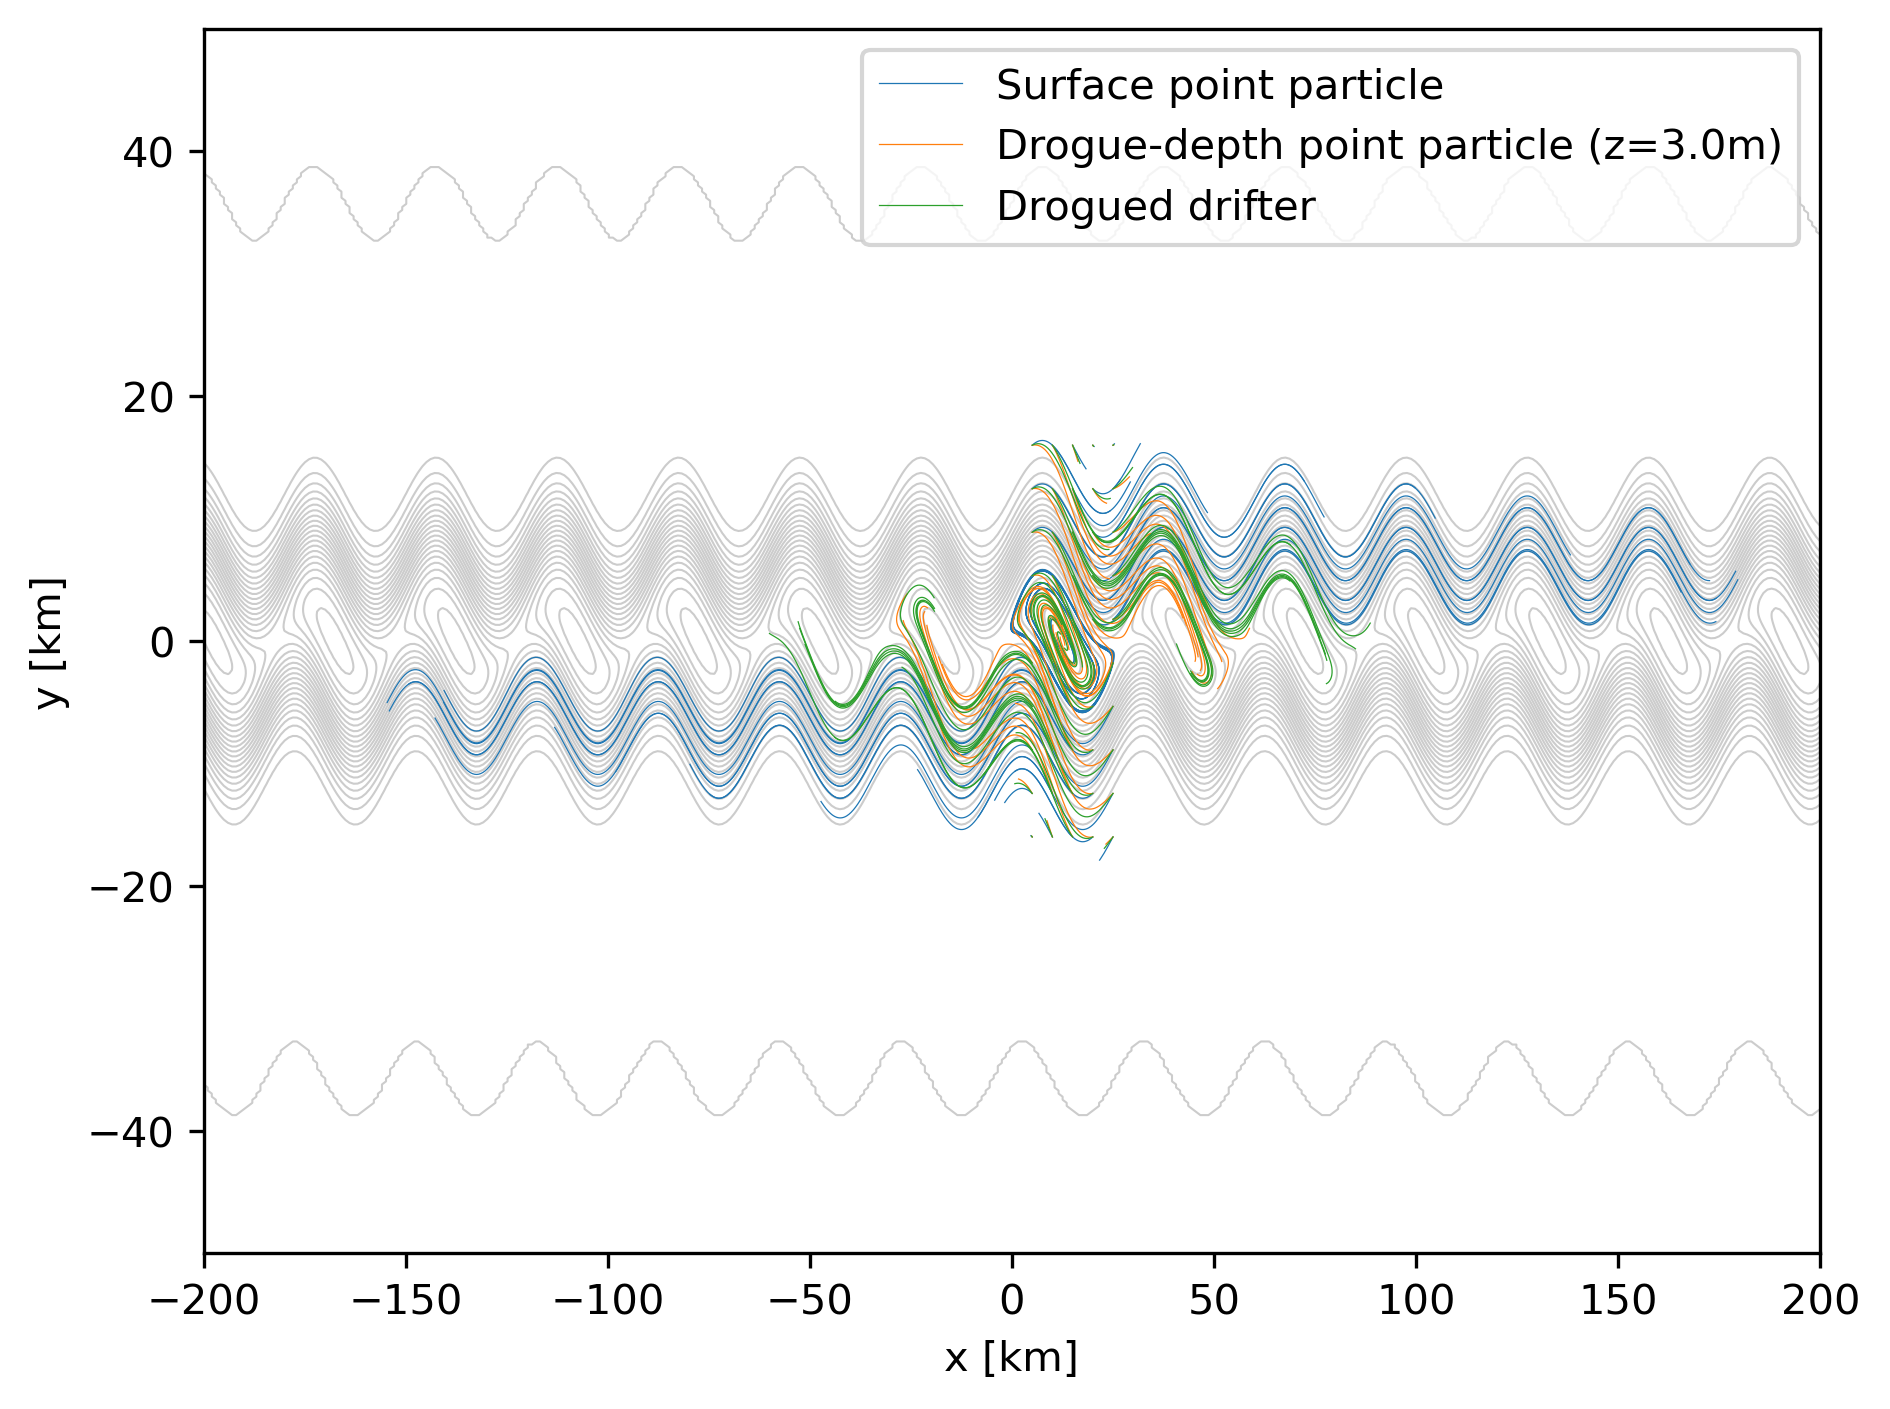

In [11]:
ds_drifter = xr.open_zarr(dd_store)
ds_surface = xr.open_zarr(surface_store)
ds_drogue = xr.open_zarr(drogue_store)

# Streamfunction contours for flow context
x_plot = np.linspace(x.min(), x.max(), 400)
y_plot = np.linspace(y.min(), y.max(), 400)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
yc1_plot = JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X_plot)
yc2_plot = -JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X_plot + MEANDER_PHASE)
C_psi = U_0 * L_Y * np.sqrt(np.pi) / 2
psi = -C_psi * erf((Y_plot - yc1_plot) / L_Y) + C_psi * erf((Y_plot - yc2_plot) / L_Y)

fig, ax = plt.subplots()
fig.set_dpi(300)
ax.contour(X_plot / 1000, Y_plot / 1000, psi, levels=25, colors="0.8", linewidths=0.5)

for i in range(ds_surface.sizes["trajectory"]):
    lon_i = ds_surface.lon.isel(trajectory=i)
    lat_i = ds_surface.lat.isel(trajectory=i)
    ax.plot(lon_i / 1000, lat_i / 1000, color="tab:blue", linewidth=0.3,
            label="Surface point particle" if i == 0 else None)

for i in range(ds_drogue.sizes["trajectory"]):
    lon_i = ds_drogue.lon.isel(trajectory=i)
    lat_i = ds_drogue.lat.isel(trajectory=i)
    ax.plot(lon_i / 1000, lat_i / 1000, color="tab:orange", linewidth=0.3,
            label=f"Drogue-depth point particle (z={DROGUE_DEPTH}m)" if i == 0 else None)

for i in range(ds_drifter.sizes["trajectory"]):
    lon_i = ds_drifter.lon.isel(trajectory=i)
    lat_i = ds_drifter.lat.isel(trajectory=i)
    ax.plot(lon_i / 1000, lat_i / 1000, color="tab:green", linewidth=0.3,
            label="Drogued drifter" if i == 0 else None)

ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Compute mean drift speeds from final positions
def compute_mean_drift_speed(ds, runtime):
    """Compute mean drift speed from final particle positions.
    
    Args:
        ds: Zarr dataset from ParticleFile output
        runtime: Total simulation time [seconds]
    
    Returns:
        Mean drift speed [m/s] across all particles
    """
    # Get initial and final positions for each trajectory
    lon_init = ds.lon.isel(obs=0)
    lat_init = ds.lat.isel(obs=0)
    
    # Find the last valid (non-NaN) position for each trajectory
    lon_final = np.full(ds.sizes["trajectory"], np.nan)
    lat_final = np.full(ds.sizes["trajectory"], np.nan)
    
    for i in range(ds.sizes["trajectory"]):
        valid = np.isfinite(ds.lon.isel(trajectory=i).values)
        if np.any(valid):
            lon_final[i] = ds.lon.isel(trajectory=i).values[valid][-1]
            lat_final[i] = ds.lat.isel(trajectory=i).values[valid][-1]
    
    # Compute displacement for each particle
    dx = lon_final - lon_init.values
    dy = lat_final - lat_init.values
    displacement = np.sqrt(dx**2 + dy**2)
    
    # Compute mean drift speed
    mean_speed = np.nanmean(displacement) / runtime
    return mean_speed

speed_dd = compute_mean_drift_speed(ds_drifter, RUNTIME)
speed_surface = compute_mean_drift_speed(ds_surface, RUNTIME)
speed_drogue = compute_mean_drift_speed(ds_drogue, RUNTIME)

print(f"Mean drift speed — Surface point particle:       {speed_surface:.4f} m/s")
print(f"Mean drift speed — Drogue-depth point particle:  {speed_drogue:.4f} m/s")
print(f"Mean drift speed — Drogued drifter:              {speed_dd:.4f} m/s")
print(f"\nDrogued drifter is {100 * (speed_surface - speed_dd) / (speed_surface - speed_drogue):.1f}% between surface and drogue-depth.")

Mean drift speed — Surface point particle:       0.7641 m/s
Mean drift speed — Drogue-depth point particle:  0.2028 m/s
Mean drift speed — Drogued drifter:              0.3325 m/s

Drogued drifter is 76.9% between surface and drogue-depth.
